In [6]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
iris = load_iris()

In [13]:
x = iris.data
y = iris.target

In [10]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

<Axes: >

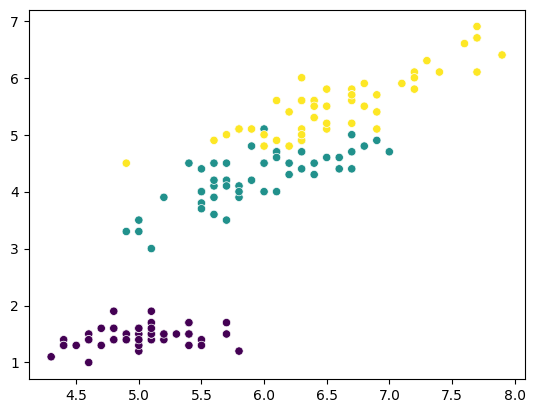

In [18]:
sns.scatterplot(x=x[:,0], y=x[:,2],c=y)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
x_scaled = scaler.fit_transform(x)

In [29]:
# optimal - dimentionality reduction using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(x_scaled)

In [30]:
# elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters= k)
    kmeans.fit(pca_data )
    wcss.append(kmeans.inertia_)

<Axes: >

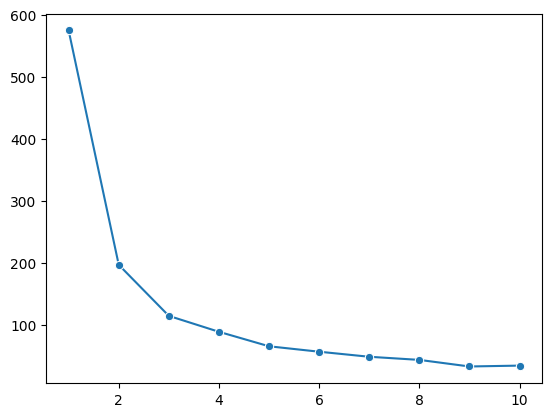

In [31]:
sns.lineplot(x=range(1,11),y=wcss, marker='o')

<Axes: >

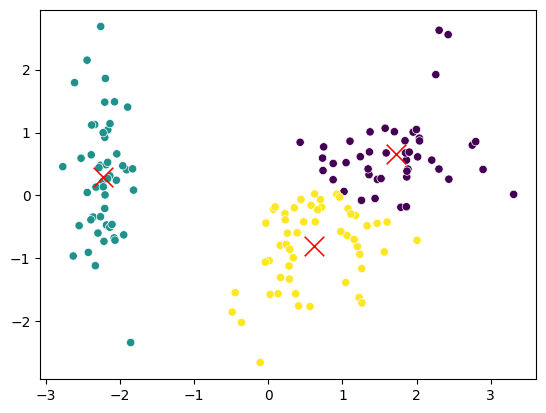

In [36]:
#KMeans

kmeans=KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data [:,0], y=pca_data [:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker="x",c="red",s=200)